# Emissions intensity: process against electricity (smelter only)

All sixteen runs, laid out the same way: carbon capture regime down the rows, GCAM ambition
scenario (SSP-RCP pair) across the columns.

## How the split is made

Process is the smelter anode term — anode CO2, PFCs and anode thermal — read from the model's own
emission factors: a smelter technology whose power source is not captive fossil has no power
generation in its scope 1, so that scope 1 is the pure anode figure (constant across the 16 regions
and 31 years). Electricity is everything left on the smelter side: captive generation inside scope
1 plus purchased power as scope 2.

Refining is **excluded** here — it is inert to the grid/CCS levers and was not re-run on GCAM
demand, so mixing its old-demand emissions with the GCAM smelter would distort the intensity.
Interim stand-in GCAM runs.

In [1]:
import sys
import importlib
sys.path.append("../..")

import common
importlib.reload(common)   # pick up edits to common.py without restarting the kernel

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import (RUNS_INDEX, CCS_ORDER, CCS_LABELS, GRIDS, GRID_LABELS,
                    GRID_COLOURS, CAPTION, run_name, style, emissions, budget, production,
                    production_by_technology, intensity_split, process_emission_factors,
                    power_source, capture_grid, label_rows, add_caption, overlaid, year_axis, save)

style()
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
factors = process_emission_factors()
print("Smelter process (anode) emission factors, tCO2 per tonne aluminium")
print(factors.round(3).to_string())

def smelter_split(n):
    smelt = production_by_technology(n, "smelter")
    al = smelt.sum(axis=1)
    proc = sum(smelt[t] * factors[t.split(" + ", 1)[0]] for t in smelt.columns)   # anode process
    tot = emissions(n, "smelter")
    return pd.DataFrame({"Process": proc / al, "Electricity": (tot - proc) / al})

ALL = list(RUNS_INDEX)
split = {n: smelter_split(n) for n in ALL}
print(f"\nloaded {len(ALL)} runs (smelter-only intensity)")

Smelter process (anode) emission factors, tCO2 per tonne aluminium
anode
Carbon Anode       2.09
Carbon Anode+CCS   1.14
Inert Anode        0.06



loaded 16 runs (smelter-only intensity)


## Process and electricity intensity, stacked

Panel height is the total intensity; the split within it is the two components.

wrote figures/emissions_intensity_process_vs_electricity.png and .svg


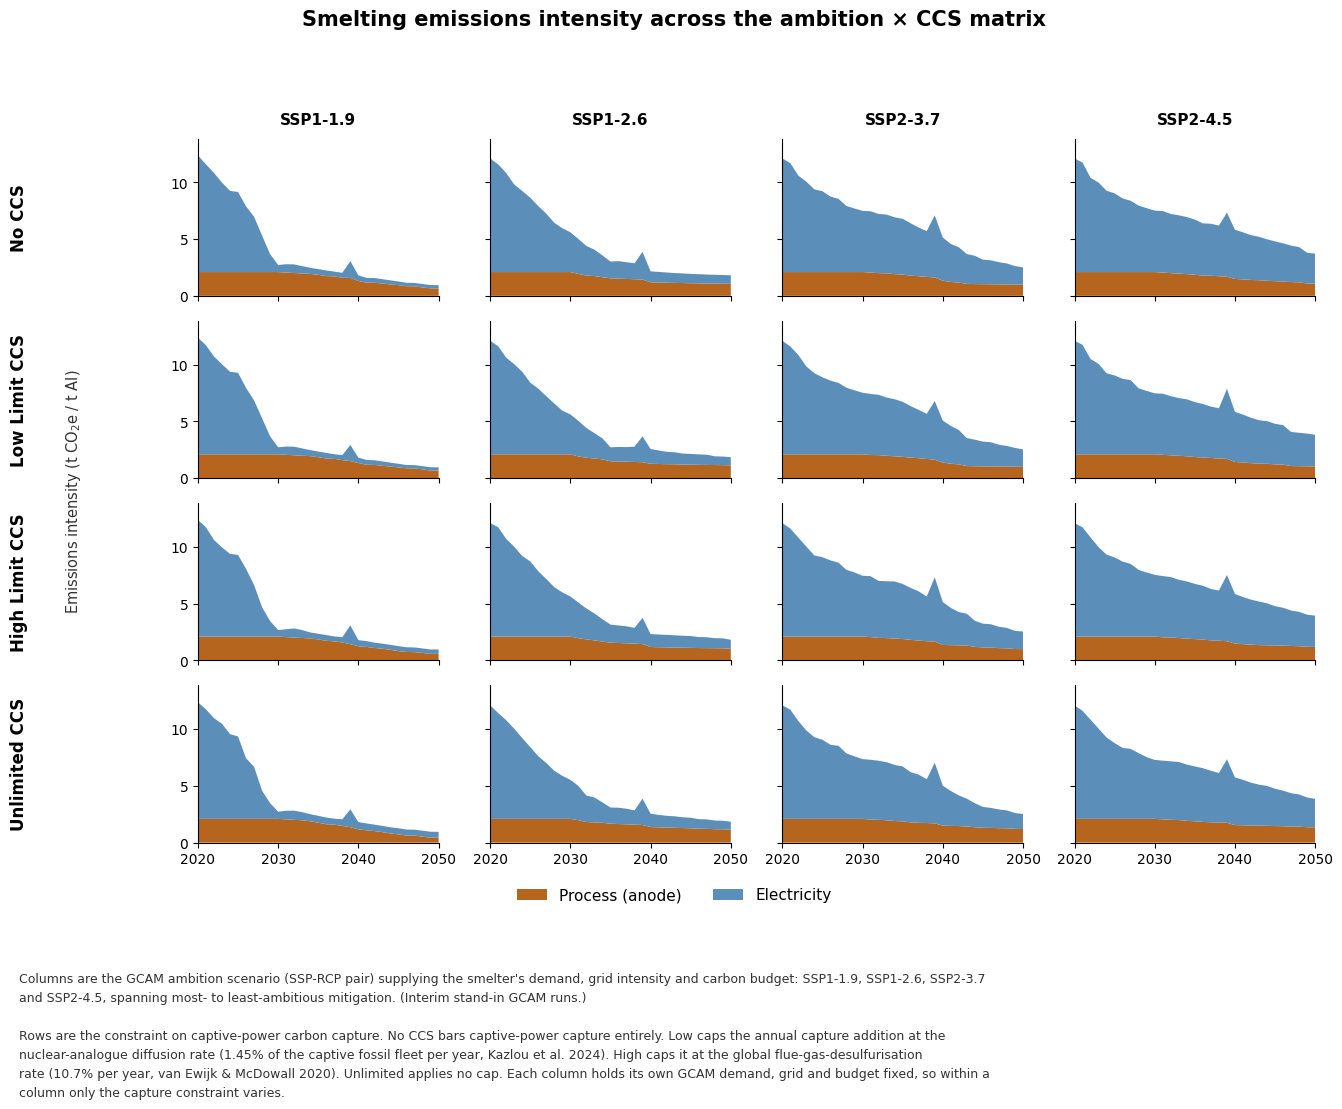

In [3]:
fig, axes = capture_grid(figsize=(13.5, 11.2))
ymax = max((split[n]["Process"] + split[n]["Electricity"]).max() for n in ALL) * 1.12
for ccs in CCS_ORDER:
    for grid in GRIDS:
        ax = axes[(ccs, grid)]
        d = split[run_name(grid, ccs)]
        ax.stackplot(d.index, d["Process"], d["Electricity"],
                     colors=["#b5651d", "#5b8fb9"], labels=["Process (anode)", "Electricity"])
        ax.grid(False)
        ax.set_ylim(0, ymax)
handles, labels = axes[(CCS_ORDER[0], GRIDS[0])].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, 0.175))
fig.suptitle("Smelting emissions intensity across the ambition \u00d7 CCS matrix",
             fontsize=15, fontweight="bold", y=0.985)
fig.tight_layout(rect=[0.105, 0.205, 1, 0.94])
label_rows(axes, "Emissions intensity (t CO$_2$e / t Al)")
add_caption(fig, y=0.012)
save(fig, "emissions_intensity_process_vs_electricity")
plt.show()

## Process intensity alone

The smelter anode process term. In 2025 it is ~2.09 t CO2/t (all carbon anode, `Carbon Anode`
scope-1 factor) and falls toward the inert-anode floor (~0.06) as inert anode penetrates. This is
smelter anode only; refining process emissions are excluded (see above).

In [4]:
years = [2025, 2030, 2035, 2040, 2045, 2050]
table = pd.DataFrame({run_name(g, ccs): split[run_name(g, ccs)]["Process"]
                      for g in GRIDS for ccs in CCS_ORDER}).loc[years]
display(table.T.round(2))
print("Smelter anode process only; 2025 ~2.09 t/t (all carbon anode) -> inert floor ~0.06")

year,2025,2030,2035,2040,2045,2050
SSP1_1p9_none,2.09,2.09,1.85,1.31,0.94,0.65
SSP1_1p9_low,2.09,2.09,1.84,1.32,0.94,0.66
SSP1_1p9_high,2.09,2.09,1.84,1.24,0.81,0.57
SSP1_1p9_unlimited,2.09,2.09,1.76,1.17,0.72,0.44
SSP1_2p6_none,2.09,2.09,1.54,1.19,1.11,1.06
SSP1_2p6_low,2.09,2.09,1.49,1.26,1.19,1.13
SSP1_2p6_high,2.09,2.09,1.56,1.18,1.10,1.03
SSP1_2p6_unlimited,2.09,2.09,1.67,1.37,1.26,1.15
SSP2_3p7_none,2.09,2.09,1.87,1.33,1.03,0.99
SSP2_3p7_low,2.09,2.09,1.87,1.37,1.03,0.99


Smelter anode process only; 2025 ~2.09 t/t (all carbon anode) -> inert floor ~0.06
